In [2]:
!wsl curl -o dataset/produccion-agricola.json "https://www.datos.gov.co/resource/t2ca-uae5.json?\$limit=50000"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file dataset/produccion-agricola.json: No such 

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 15464 bytes


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
#from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score,  precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, FunctionTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders.binary import BinaryEncoder
import phik
from phik import resources
from phik.binning import bin_data
from phik.decorators import *
from phik.report import  plot_correlation_matrix
import networkx as nx

In [ ]:
#Modelo semántico



In [115]:
df.sample(10).to_csv('data/sample.csv', index=False)

In [42]:
df = pd.read_json('data/produccion-agricola.json')
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32721 entries, 0 to 32720
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo                32721 non-null  object 
 1   rubro               32721 non-null  object 
 2   subregion           32721 non-null  object 
 3   anio                32721 non-null  int64  
 4   municipio           32721 non-null  object 
 5   area_total          32721 non-null  float64
 6   area_produccion     32721 non-null  float64
 7   volumen_produccion  32721 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [ ]:
df.describe()

,anio,area_total,area_produccion,volumen_produccion
count,32721.000000,32680.000000,32287.000000,3.253500e+04
mean,2009.716787,435.615817,399.454878,3.145023e+03
std,8.894551,1223.919511,1145.616547,2.322381e+04
min,1990.000000,0.000000,-1.000000,-1.065810e-14
25%,2003.000000,19.700000,15.000000,5.580000e+01
50%,2011.000000,76.000000,65.000000,2.880000e+02
75%,2017.000000,315.000000,285.000000,1.276000e+03
max,2022.000000,36000.000000,36000.000000,1.039280e+06


In [ ]:
df.describe(include='O')

,tipo,rubro,subregion,municipio
count,32721,32721,32721,32721
unique,3,155,9,140
top,Permanentes,Café,Oriente,Medellín
freq,19753,2799,6802,732


c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

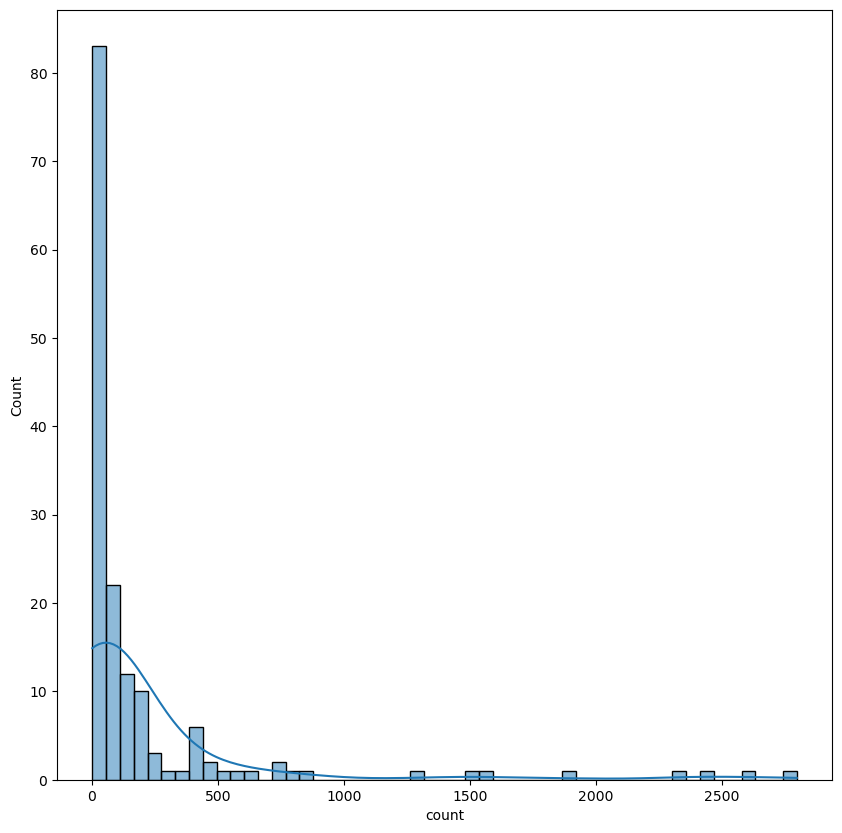

In [6]:
plt.figure(figsize=(10, 10))
sns.histplot(df['rubro'].value_counts(), kde=True)

In [7]:
df['rubro'].value_counts().mean()

211.1032258064516

In [43]:
# Combinar clases con menos de 20 muestras en "Otros"
for i in df.select_dtypes(include='O').columns:
    counts = df[i].value_counts()
    to_group = counts[counts < 100].index
    df[i] = df[i].apply(lambda x: 'Otros' if x in to_group else x)

df[df['municipio'] == 'Otros']

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
2582,Transitorios,Papa,Norte,1995,Otros,10.0,10.0,280.0
3237,Transitorios,Papa,Norte,1996,Otros,11.0,11.0,310.0
3892,Transitorios,Papa,Norte,1997,Otros,12.0,12.0,204.0
4554,Permanentes,Naranja Valencia,Suroeste,1998,Otros,18.0,15.0,300.0
4579,Transitorios,Papa,Norte,1998,Otros,14.0,14.0,246.0
...,...,...,...,...,...,...,...,...
32401,Permanentes,Plátano En Asocio,Valle de Aburra,2022,Otros,10.0,8.0,20.8
32517,Transitorios,Tomate Chonto,Valle de Aburra,2022,Otros,2.0,1.8,12.6
32592,Transitorios,Tomate Chonto Bajo Invernadero,Valle de Aburra,2022,Otros,2.0,2.0,120.0
32664,Anuales,Yuca,Suroeste,2022,Otros,2.5,1.5,12.0


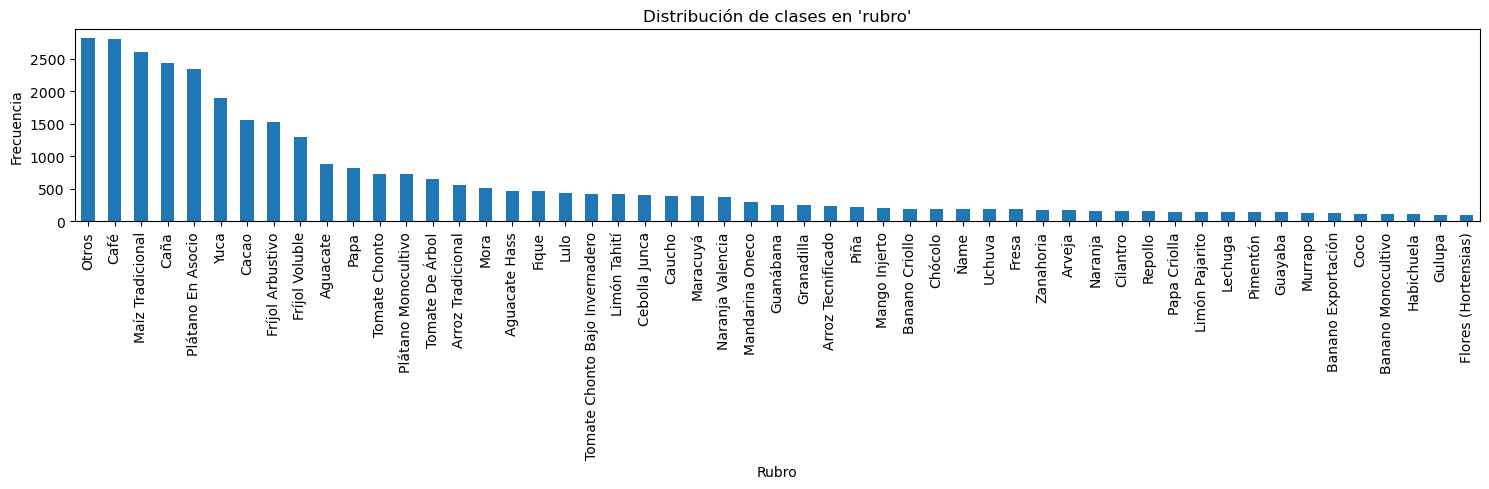

In [9]:
df['rubro'].value_counts().plot(kind='bar', figsize=(15,5))
plt.title("Distribución de clases en 'rubro'")
plt.ylabel("Frecuencia")
plt.xlabel("Rubro")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [11]:
frecuencia = df['rubro'].value_counts()
media  = frecuencia.mean()
desviacion = frecuencia.std()
variacion = desviacion / media
print(f"Media: {media:.1f}")
print(f"Desv. estándar: {desviacion:.1f}")
print(f"Coef. variación  : {variacion:.2f}")

Media: 617.4
Desv. estándar: 755.0
Coef. variación  : 1.22


In [ ]:
df['municipio'].value_counts()

municipio
Medellín                732
Marinilla               575
Urrao                   549
El Carmen de Viboral    509
Támesis                 502
                       ... 
La Ceja                 242
Caucasia                242
Concepción              241
Puerto Berrío           241
San Juan de Urabá       239
Name: count, Length: 70, dtype: int64

In [12]:
freq = df['municipio'].value_counts()
mu  = freq.mean()
sigma = freq.std()
cv = sigma / mu
print(f"Media (μ)    : {mu:.1f}")
print(f"Desv. estándar (σ): {sigma:.1f}")
print(f"Coef. variación  : {cv:.2f}")


Media (μ)    : 268.2
Desv. estándar (σ): 94.8
Coef. variación  : 0.35


c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


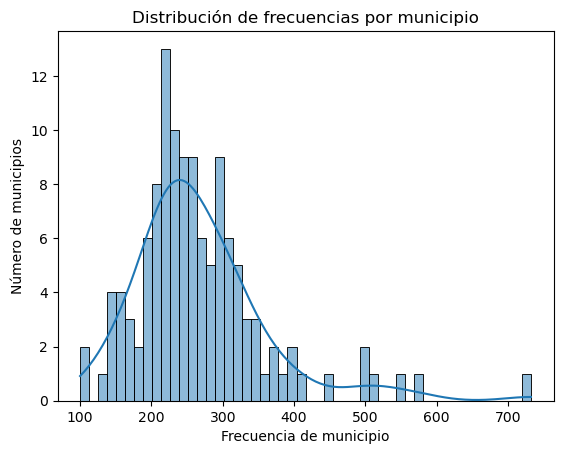

In [24]:
sns.histplot(df['municipio'].value_counts(), bins=50, kde=True)
plt.xlabel("Frecuencia de municipio")
plt.ylabel("Número de municipios")
plt.title("Distribución de frecuencias por municipio")
plt.show()

In [ ]:
#Imputar valores nulos
areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
for i in df['tipo'].unique():
    for j in areas:
        media = df[df['tipo'] == i][j].mean()
        df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)

In [ ]:
df.groupby(['tipo'])['volumen_produccion'].mean()

tipo
Anuales         2257.987454
Permanentes     3861.514644
Transitorios    2016.794965
Name: volumen_produccion, dtype: float64

In [72]:
#Manejar duplicados
print(f'Total valores duplicados: {df.duplicated().sum()}')
print(f'\nVisualizar duplicados: \n{df[df.duplicated()]}')
df.drop_duplicates(inplace=True)
print(f'\nEliminar duplicados... \n\t Total valores duplicados: {df.duplicated().sum()}')

Total valores duplicados: 7

Visualizar duplicados: 
              tipo                rubro   subregion  anio  municipio  \
2268   Permanentes                 Caña       Norte  1995  Guadalupe   
2554   Permanentes              Naranja   Occidente  1995      Olaya   
2630   Permanentes    Plátano En Asocio       Norte  1995    Ituango   
5292   Permanentes                 Mora       Norte  1999    Yarumal   
5432   Permanentes    Plátano En Asocio    Nordeste  1999    Vegachí   
5435   Permanentes    Plátano En Asocio    Nordeste  1999       Yalí   
13067  Permanentes  Plátano Monocultivo  Bajo Cauca  2008   El Bagre   

       area_total  area_produccion  volumen_produccion  
2268        267.0            262.0              1257.6  
2554         11.8              7.3               149.2  
2630         85.7             80.7               201.8  
5292          5.5              3.0                15.0  
5432         69.5             67.5               405.0  
5435         85.0           

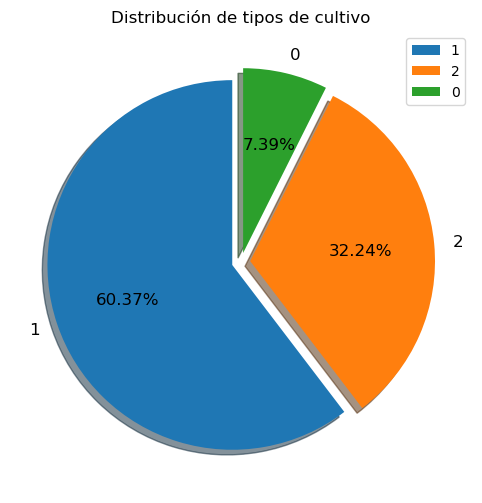

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df['tipo'].value_counts(), 
        labels=df['tipo'].unique(), 
        autopct='%0.2f%%', startangle=90, shadow=True, 
        explode=(0.05, 0.05, 0.05),      
        textprops={'fontsize': 12} )
plt.title('Distribución de tipos de cultivo')
plt.legend(df['tipo'].unique())
plt.show()

Text(0.5, 1.0, 'Top 10 Rubros')

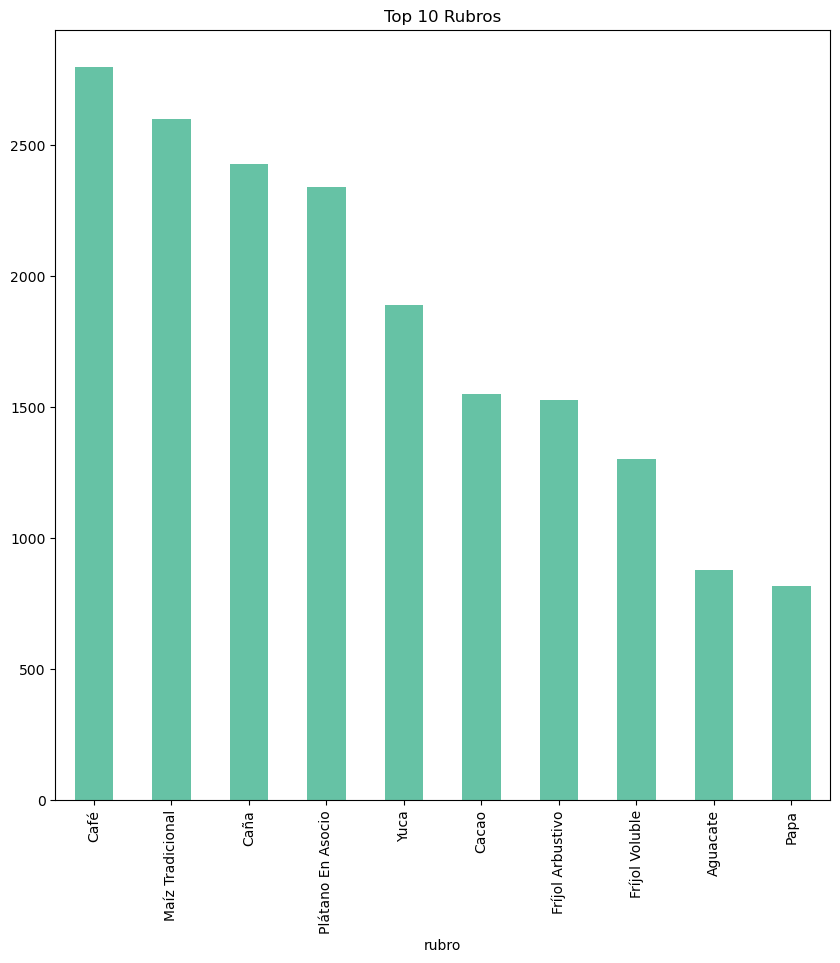

In [ ]:
plt.figure(figsize=(10, 10))
df['rubro'].value_counts().head(10).plot(kind='bar', colormap='Set2')
plt.title('Top 10 Rubros')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

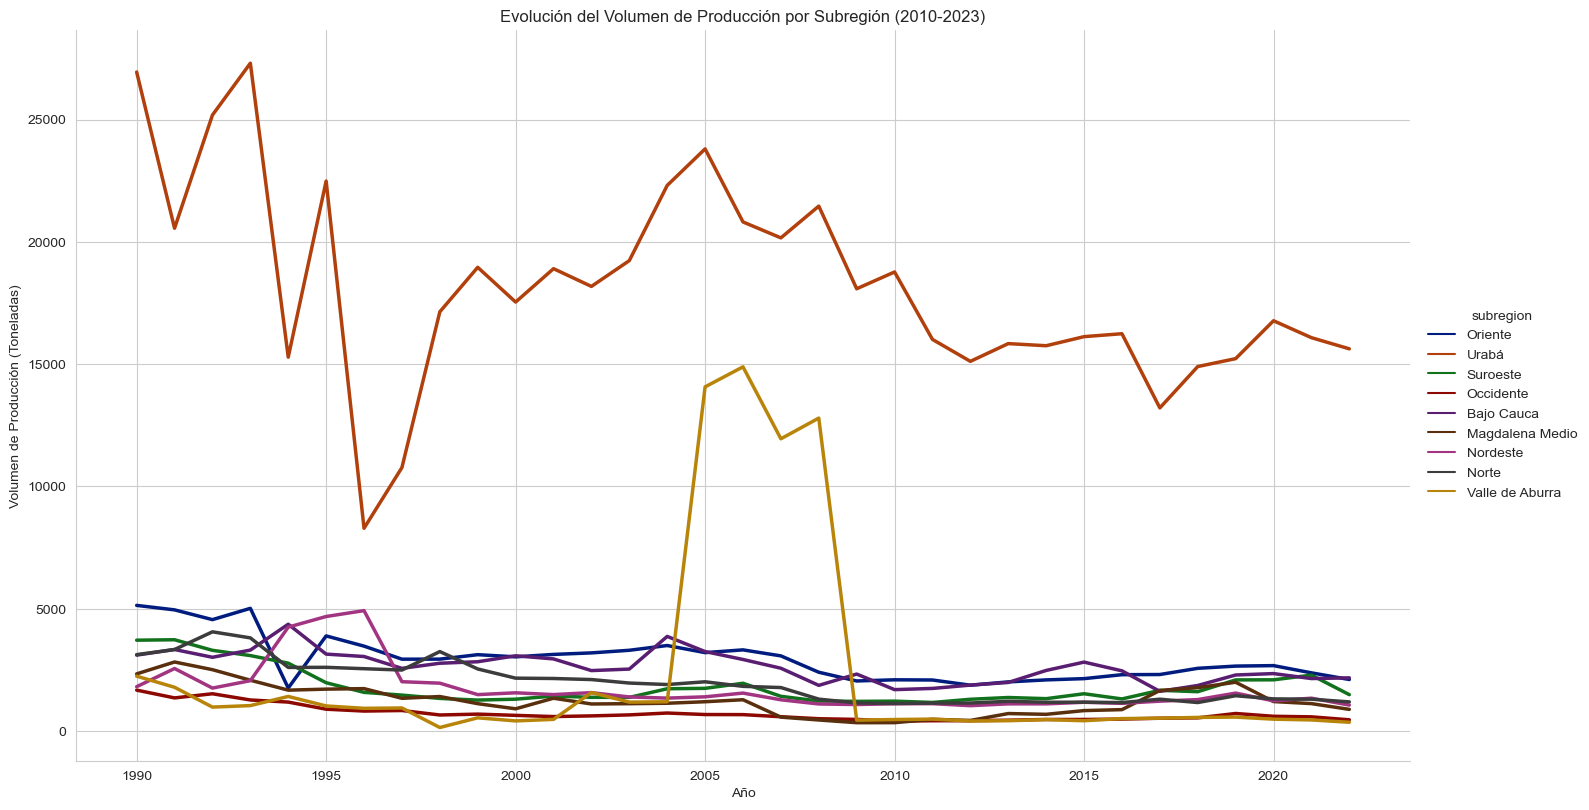

In [ ]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    aspect=1.8,  # Relación ancho/alto
    palette='dark',  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

In [ ]:
df['volumen_produccion']/df['area_produccion']

0         6.0
1        15.0
2         6.5
3         7.0
4        15.0
         ... 
32716     5.0
32717     2.0
32718     5.0
32719    13.5
32720     6.0
Length: 32721, dtype: float64

In [ ]:
df['area_produccion']/df['area_total']

0        0.511111
1        0.931034
2        0.705882
3        0.933333
4        0.733333
           ...   
32716    1.000000
32717    0.304348
32718    1.000000
32719    1.000000
32720    1.000000
Length: 32721, dtype: float64

(array([-50.,   0.,  50., 100., 150., 200., 250., 300., 350.]),
 [Text(-50.0, 0, '(Cilantro, Suroeste)'),
  Text(0.0, 0, '(Banano Exportación, Urabá)'),
  Text(50.0, 0, '(Tomate De Árbol, Suroeste)'),
  Text(100.0, 0, '(Aguacate, Suroeste)'),
  Text(150.0, 0, '(Aguacate Hass, Norte)'),
  Text(200.0, 0, '(Maracuyá, Bajo Cauca)'),
  Text(250.0, 0, '(Aguacate, Magdalena Medio)'),
  Text(300.0, 0, '(Fríjol Arbustivo, Magdalena Medio)'),
  Text(350.0, 0, '')])

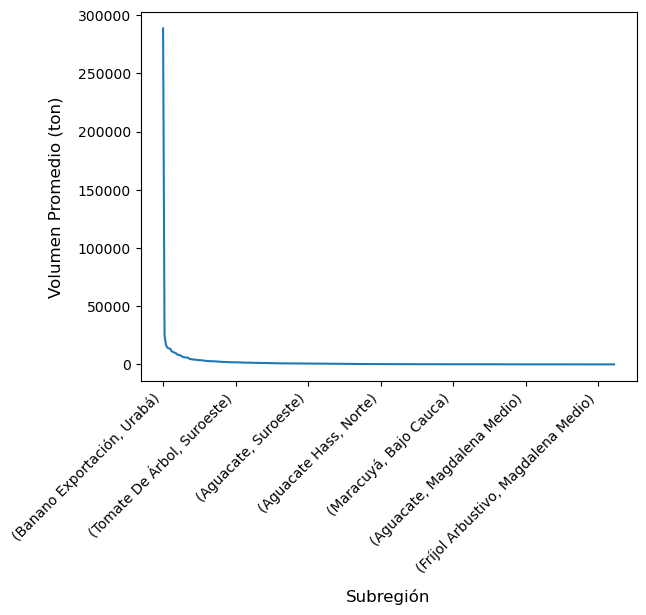

In [28]:
df.groupby(['rubro','subregion'])['volumen_produccion'].mean().sort_values(ascending=False).plot(kind='line')
plt.xlabel('Subregión', 
           fontsize=12, 
           labelpad=10)         # Espaciado de la etiqueta

plt.ylabel('Volumen Promedio (ton)', 
           fontsize=12, 
           labelpad=10)


plt.xticks(rotation=45, ha='right')  # Alineación a la derecha

In [27]:
df.groupby('subregion')['rubro'].count()

subregion
Bajo Cauca         1243
Magdalena Medio    1341
Nordeste           2290
Norte              3946
Occidente          5308
Oriente            6802
Suroeste           6748
Urabá              2838
Valle de Aburra    2205
Name: rubro, dtype: int64

<Axes: xlabel='subregion'>

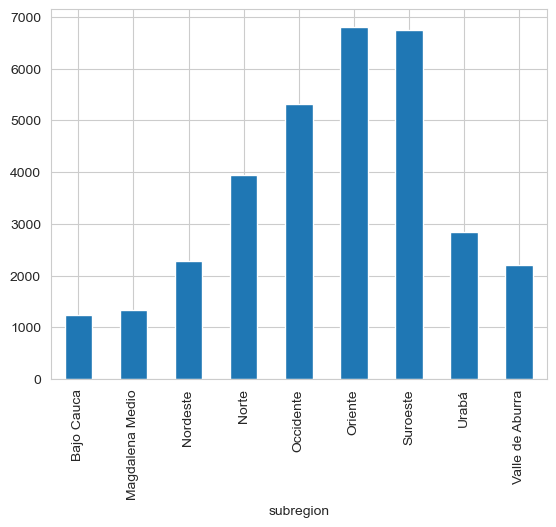

In [ ]:
df.groupby('subregion')['rubro'].count().plot(kind='bar')

<Axes: xlabel='rubro'>

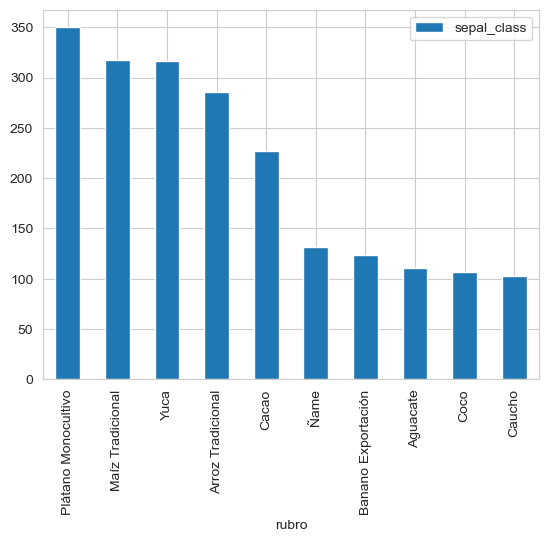

In [ ]:
df[df['subregion']=='Urabá'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10).plot(kind='bar', x='rubro', y='sepal_class')

In [ ]:
df[df['subregion']=='Oriente'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10)

,subregion,rubro,sepal_class
18,Oriente,Café,551
37,Oriente,Fríjol Voluble,496
60,Oriente,Papa,420
20,Oriente,Caña,417
68,Oriente,Plátano En Asocio,386
54,Oriente,Maíz Tradicional,358
55,Oriente,Mora,268
76,Oriente,Tomate De Árbol,265
79,Oriente,Yuca,232
17,Oriente,Cacao,206


In [ ]:
#de que tipo son los rubros mas comunes
df.groupby(['tipo', 'rubro']).size().reset_index(name='sepal_class').sort_values(by='sepal_class', ascending=False)

,tipo,rubro,sepal_class
29,1,Café,2799
145,2,Maíz Tradicional,2599
33,1,Caña,2429
101,1,Plátano En Asocio,2338
7,0,Yuca,1889
...,...,...,...
75,1,Mandarina Común,1
103,1,Plátano X Borojó,1
11,1,Achin,1
18,1,Aguacate lorena,1


c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping wi

<Axes: xlabel='volumen_produccion', ylabel='Count'>

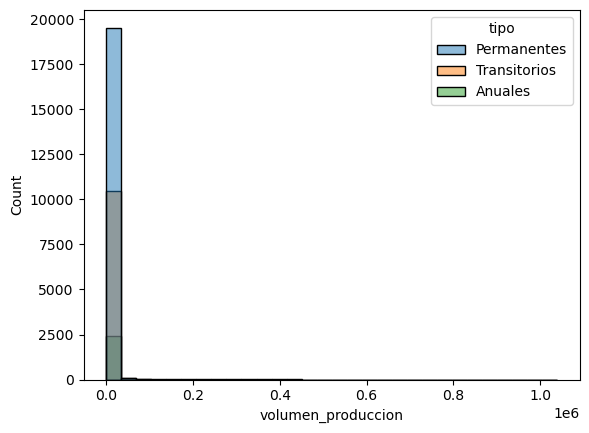

In [57]:
sns.histplot(data=df, hue='tipo', x='volumen_produccion', bins=30)

In [ ]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    #aspect=1.8,  # Relación ancho/alto
    #palette=,  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13928\3183495050.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas


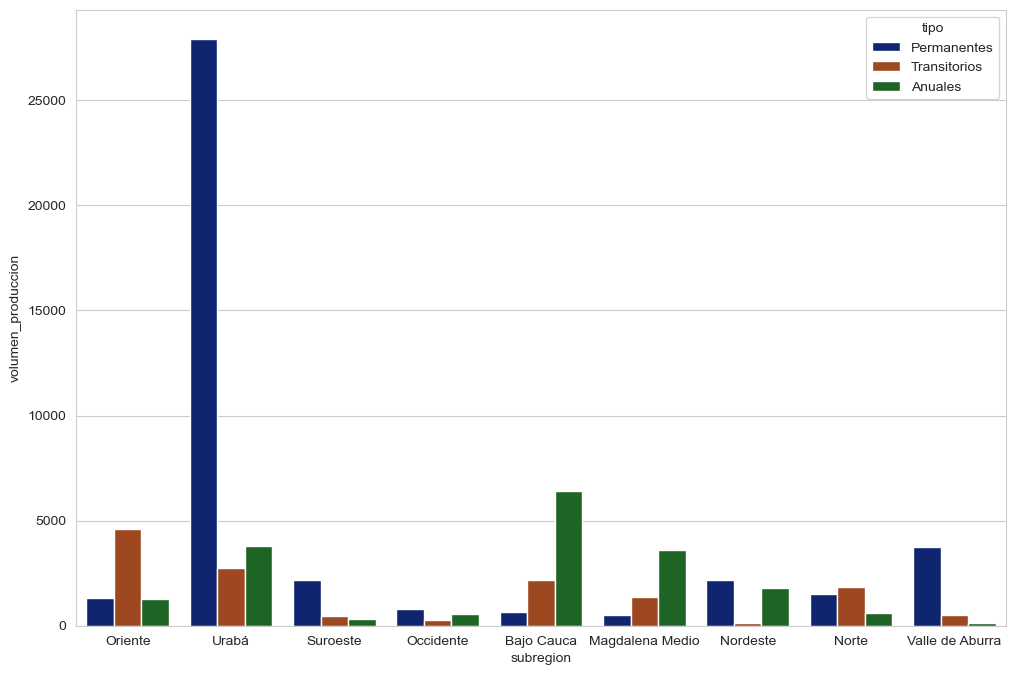

In [ ]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas
    ci=None,
    palette='dark',  # Mejor esquema de colores
)


<Axes: xlabel='subregion', ylabel='area_total'>

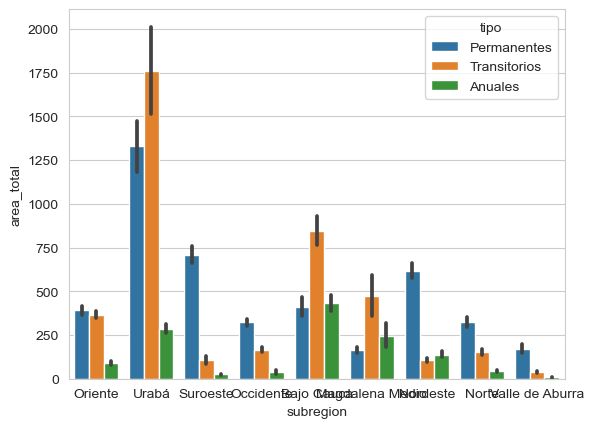

In [ ]:
sns.barplot(data=df, y='area_total', x='subregion', hue='tipo')

<Axes: xlabel='subregion', ylabel='area_total'>

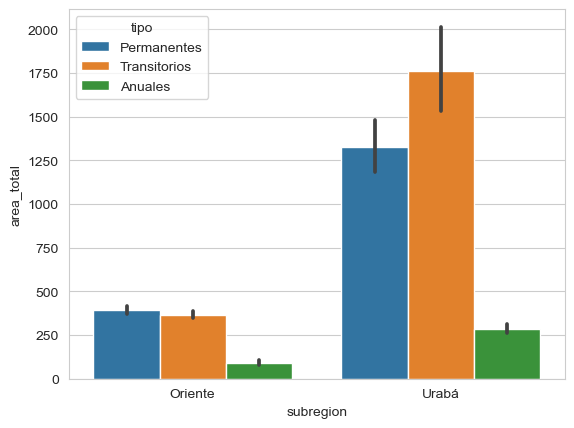

In [ ]:
sns.barplot(data=df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')], y='area_total', x='subregion', hue='tipo')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='volumen_produccion', ylabel='Count'>

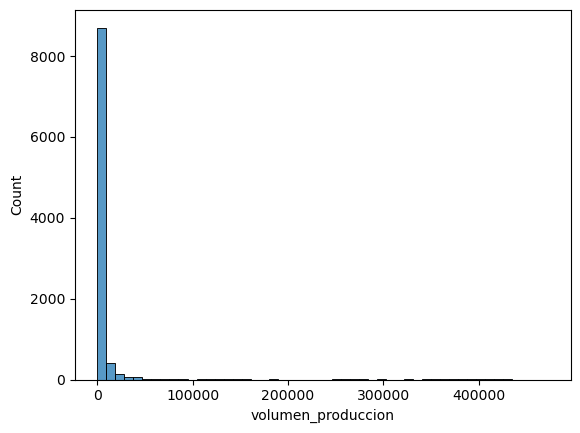

In [81]:
df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]
sns.histplot(x='volumen_produccion', data=df_filtrado, bins=50)

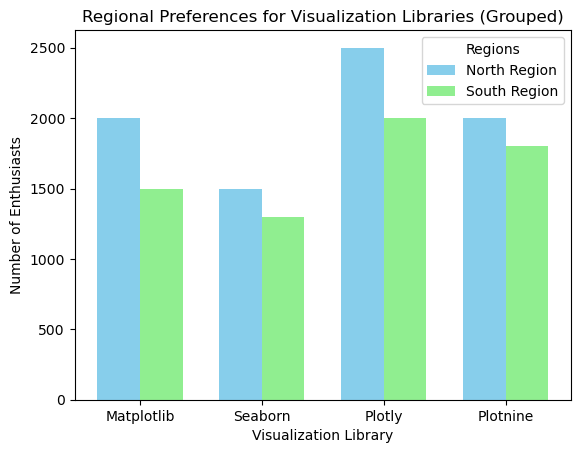

In [ ]:
# Define library names
library = ['Matplotlib', 'Seaborn', 'Plotly', 'Plotnine']

# Number of Enthusiasts for different regions
enthusiasts_north = [2000, 1500, 2500, 2000]
enthusiasts_south = [1500, 1300, 2000, 1800]
bar_width = 0.35
x = np.arange(len(library))

# Grouped Bar Plot
plt.bar(x - bar_width/2, enthusiasts_north, bar_width, label='North Region', color='skyblue')
plt.bar(x + bar_width/2, enthusiasts_south, bar_width, label='South Region', color='lightgreen')

# Adding labels and title
plt.xlabel('Visualization Library')
plt.ylabel('Number of Enthusiasts')
plt.title('Regional Preferences for Visualization Libraries (Grouped)')
plt.xticks(x, library)
plt.legend(title='Regions')
plt.show()

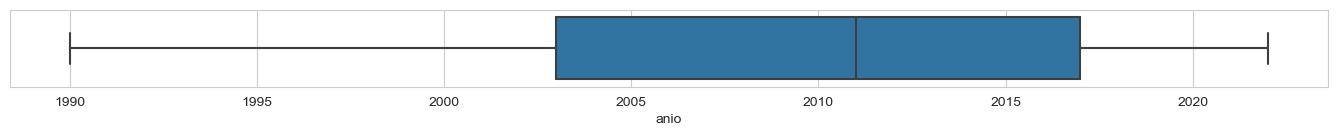

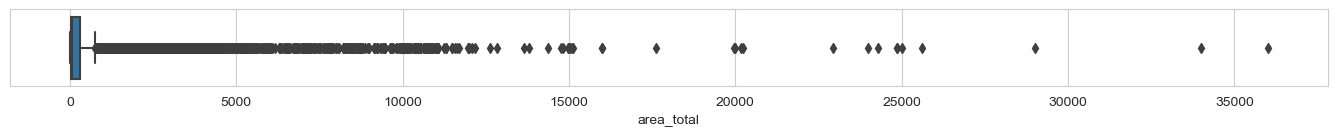

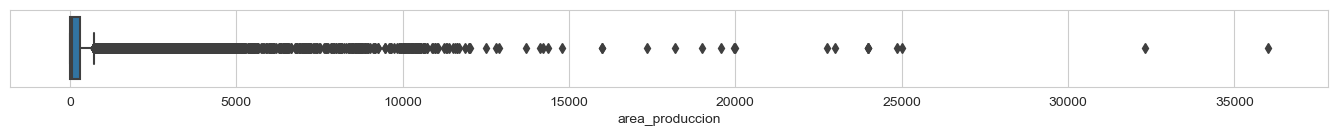

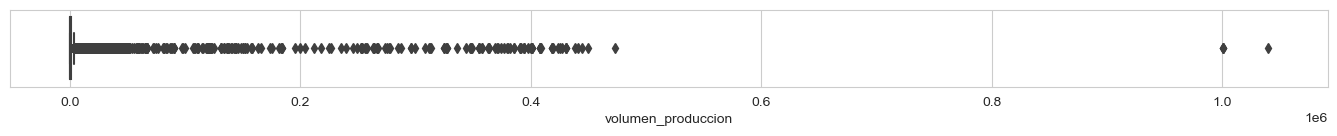

In [ ]:
cols = df.select_dtypes(include='number').columns
for i in cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[cols], x=i)

interval columns not set, guessing: ['anio', 'area_total', 'area_produccion', 'volumen_produccion']


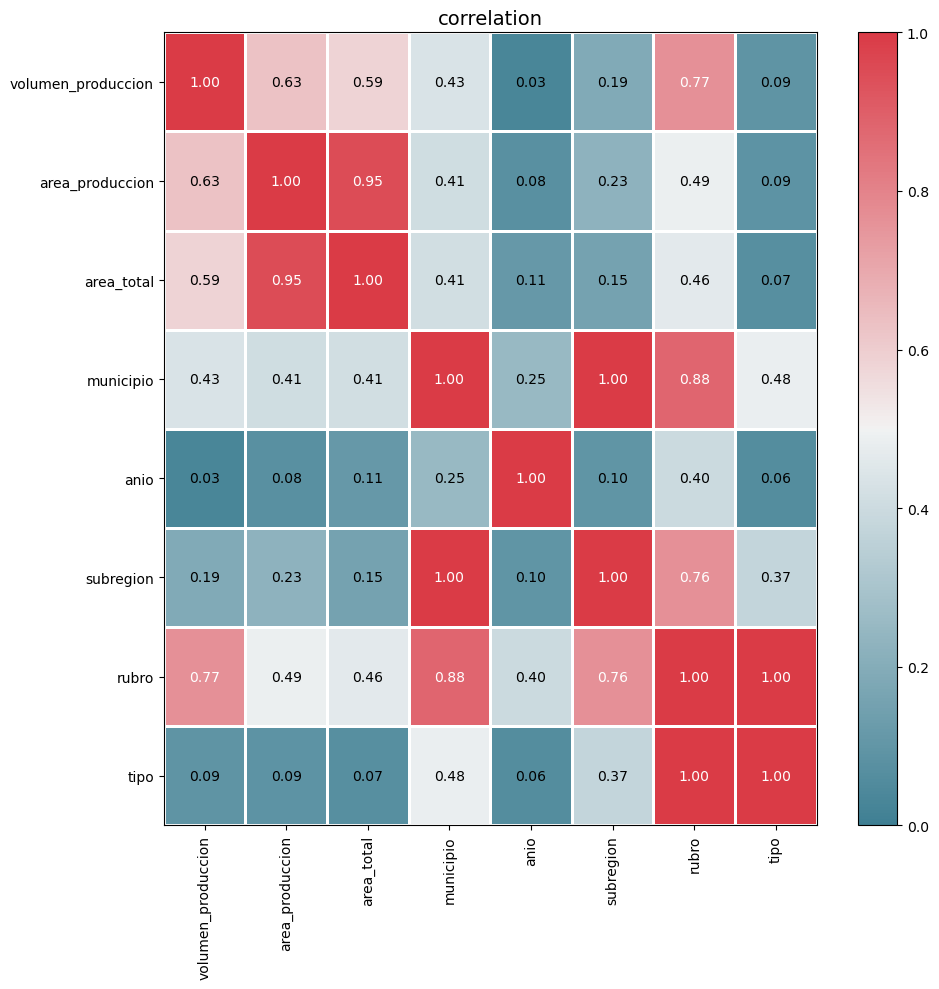

In [3]:
corre = df.phik_matrix()
cma = sns.diverging_palette(220, 10, as_cmap=True)

plot_correlation_matrix(corre.values, x_labels=corre.columns, y_labels=corre.index, vmin=0, vmax=1, color_map=cma, figsize=(10,10))

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping wi

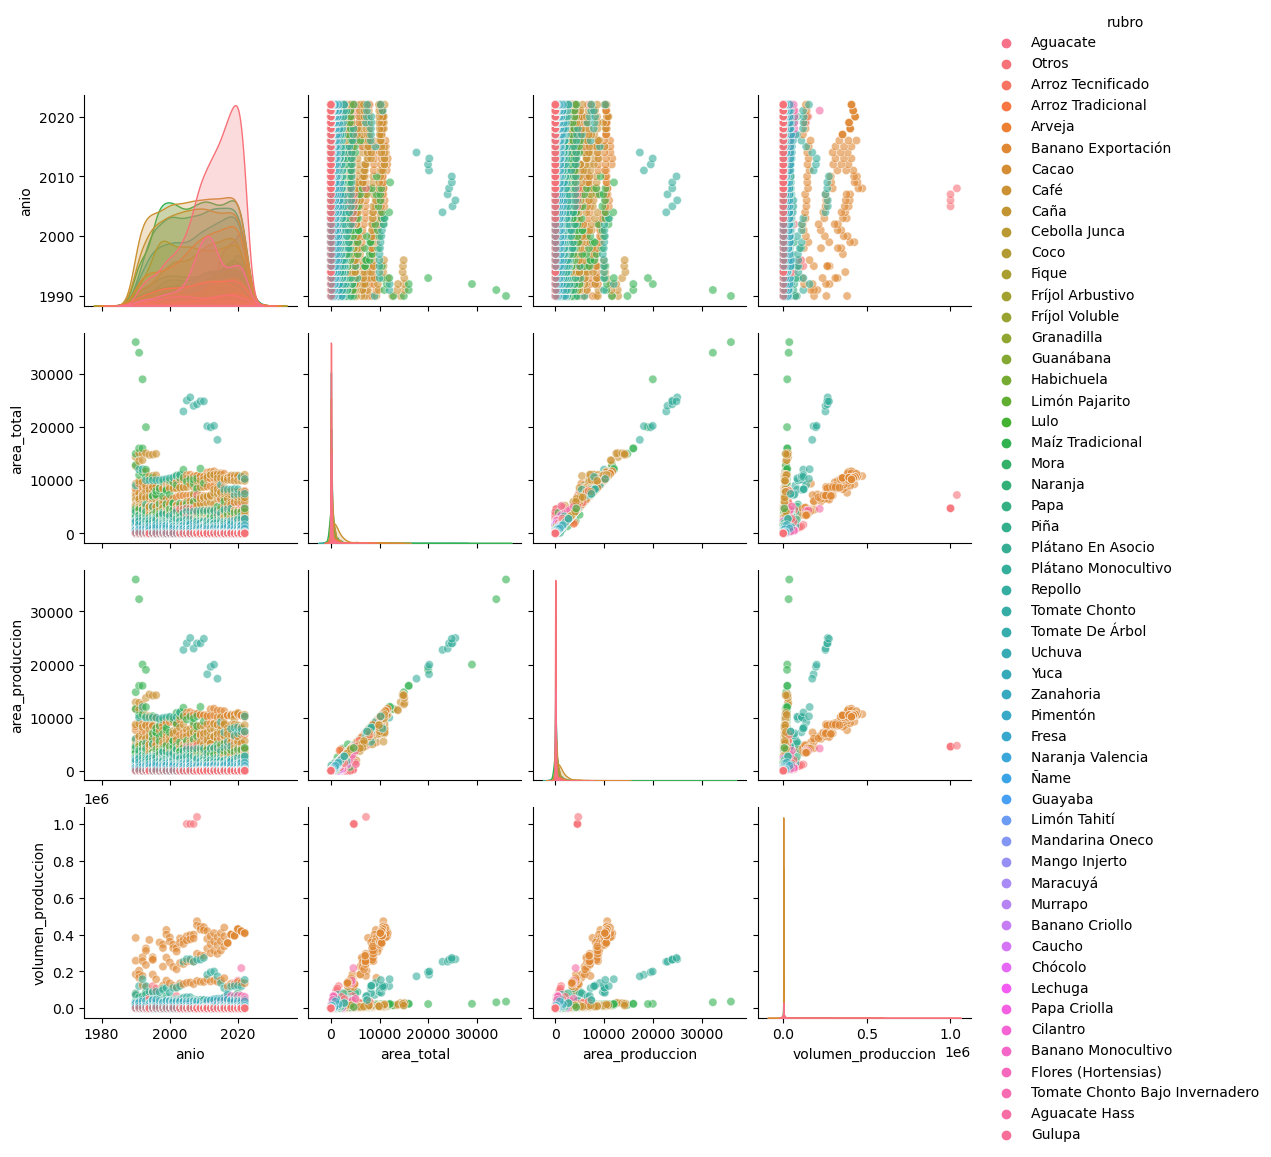

In [29]:
grafico = sns.pairplot(data=df, hue='rubro', plot_kws={'alpha': 0.6})

In [29]:
# Combinar clases con menos de 20 muestras en "Otros"
for i in df.select_dtypes(include='O').columns:
    counts = df[i].value_counts()
    to_group = counts[counts < 50].index
    df[i] = df[i].apply(lambda x: 'Otros' if x in to_group else x)

df[df['municipio'] == 'Otros']

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
2582,Transitorios,Papa,Norte,1995,Otros,10.0,10.0,280.0
3237,Transitorios,Papa,Norte,1996,Otros,11.0,11.0,310.0
3892,Transitorios,Papa,Norte,1997,Otros,12.0,12.0,204.0
4554,Permanentes,Naranja Valencia,Suroeste,1998,Otros,18.0,15.0,300.0
4579,Transitorios,Papa,Norte,1998,Otros,14.0,14.0,246.0
...,...,...,...,...,...,...,...,...
32391,Permanentes,Plátano En Asocio,Suroeste,2022,Otros,11.0,6.0,24.0
32517,Transitorios,Tomate Chonto,Valle de Aburra,2022,Otros,2.0,1.8,12.6
32592,Transitorios,Tomate Chonto Bajo Invernadero,Valle de Aburra,2022,Otros,2.0,2.0,120.0
32664,Anuales,Yuca,Suroeste,2022,Otros,2.5,1.5,12.0


In [44]:
def duplicates(df):
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Total duplicados: {duplicates}")
        print(f"Visualizar duplicados:\n{df[df.duplicated()]}")
        df.drop_duplicates(inplace=True)
        print(f"Eliminar duplicados... Total duplicados: {df.duplicated().sum()}")
    else:
        print("No se econtraron duplicados.")

duplicates(df)

Total duplicados: 16
Visualizar duplicados:
               tipo                rubro        subregion  anio  \
2268    Permanentes                 Caña            Norte  1995   
2554    Permanentes              Naranja        Occidente  1995   
2630    Permanentes    Plátano En Asocio            Norte  1995   
5292    Permanentes                 Mora            Norte  1999   
5432    Permanentes    Plátano En Asocio         Nordeste  1999   
5435    Permanentes    Plátano En Asocio         Nordeste  1999   
13067   Permanentes  Plátano Monocultivo       Bajo Cauca  2008   
13078   Permanentes                Otros            Urabá  2008   
13637  Transitorios                Otros            Norte  2009   
18909   Permanentes                Otros            Urabá  2013   
19769  Transitorios                Otros            Norte  2014   
22441   Permanentes                Otros         Suroeste  2016   
26056  Transitorios                Otros  Valle de Aburra  2018   
27254   Permanente

In [45]:
X=df.drop('rubro', axis=1)
y=df['rubro']
X.shape, y.shape

((32705, 7), (32705,))

In [46]:
#duplicates(df)
le = LabelEncoder()
le.fit(y)
Y_encoded = le.transform(y)
print(Y_encoded)

[ 0  0  0 ... 38 38 38]


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42) no es necesario pq en gridSearch se hace validacion cruzada
X_train.shape, X_test.shape

((26164, 7), (6541, 7))

In [36]:
def imputer(df):
    df=df.copy()
    areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
    for i in df['tipo'].unique():
        for j in areas:
            media = df[df['tipo'] == i][j].mean()
            df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)
    return df

preprocess_imputer = FunctionTransformer(imputer)

In [37]:
column_trans = ColumnTransformer(
    transformers=[
        ('cat_nominal', OneHotEncoder(), ['subregion']),
        ('cat_ordinal', OrdinalEncoder(), ['tipo']),
        ('cat_binary', BinaryEncoder(), ['municipio']),
        ('num', MinMaxScaler(), ['area_total', 'area_produccion', 'volumen_produccion', 'anio'])
    ],
    remainder='passthrough'  # Mantener las columnas no transformadas
)

In [38]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs'],
            'model__max_iter': [100, 200, 500],
            'model__multi_class': ['multinomial', 'ovr']
        }
    },
    'SVM': {
        'model': SVC(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(), 
        'hyperparameters' : {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__algorithm': ['auto'],
            'model__metric': ['minkowski']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(), 
        'hyperparameters' : {
            'model__criterion': ['gini', 'entropy'],
            'model__splitter': ['best'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2', None]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(), 
        'hyperparameters' : {
            'model__n_estimators': [50, 100],
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(), 
        'hyperparameters' : {
            'model__var_smoothing': [1e-9, 1e-8]
        }
    }
}

In [39]:
def create_pipeline(model):
    pipeline = Pipeline([
        #('duplicates', preprocess_duplicates),
        ('impute_nulls', preprocess_imputer),
        ('Encoders', column_trans),
        ('model', model)
    ])
    return pipeline

In [48]:
models_test = {
    'SVM': {
        'model': SVC(),
        'hyperparameters': {
            'model__C': [1],  # solo un parámetro para reducir combinaciones
            'model__kernel': ['linear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'hyperparameters': {
            'model__n_neighbors': [3]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(),
        'hyperparameters': {
            'model__C': [1],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs'],
            'model__max_iter': [200],
            'model__multi_class': ['ovr']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'hyperparameters': {
            'model__criterion': ['gini'],
            'model__splitter': ['best'],
            'model__max_depth': [10],
            'model__max_features': ['sqrt']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'hyperparameters': {
            'model__n_estimators': [100],
            'model__criterion': ['gini'],
            'model__max_depth': [10],
            'model__max_features': ['sqrt']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(),
        'hyperparameters': {
            'model__var_smoothing': [1e-08]
        }
    }
    
}

In [54]:
lista_pipelines = []
for i, j in models_test.items():
    try:
        print(f"\nEntrenando modelo: {j['model']}")
        k = create_pipeline(j['model'])
        print(f"Hiperparámetros: {j['hyperparameters']}")

        grid_s = GridSearchCV(estimator=k, param_grid=j['hyperparameters'], verbose=1, cv=3)
        print("GridSearchCV...")
        grid_s.fit(X_train, y_train)
        print(f'{i} mejores parámetros: {grid_s.best_params_}\n')

        lista_pipelines.append(grid_s.best_estimator_)
    except Exception as e:
        print(f'Error en modelo {i}: {e}\n')


Entrenando modelo: SVC()
Hiperparámetros: {'model__C': [1], 'model__kernel': ['linear']}
GridSearchCV...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

SVM mejores parámetros: {'model__C': 1, 'model__kernel': 'linear'}


Entrenando modelo: KNeighborsClassifier()
Hiperparámetros: {'model__n_neighbors': [3]}
GridSearchCV...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

KNN mejores parámetros: {'model__n_neighbors': 3}


Entrenando modelo: LogisticRegression()
Hiperparámetros: {'model__C': [1], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], 'model__max_iter': [200], 'model__multi_class': ['ovr']}
GridSearchCV...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Random Forest mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}


Entrenando modelo: GaussianNB()
Hiperparámetros: {'model__var_smoothing': [1e-08]}
GridSearchCV...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}



c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [51]:
lista_pipelines = []
for i, j in models.items():
    try:
        print(f"\nEntrenando modelo: {j['model']}")
        k = create_pipeline(j['model'])
        print(f"Hiperparámetros: {j['hyperparameters']}")

        grid_s = GridSearchCV(estimator=k, param_grid=j['hyperparameters'], verbose=1, cv=3)
        print("GridSearchCV...")
        grid_s.fit(X_train, y_train)
        print(f'{i} mejores parámetros: {grid_s.best_params_}\n')

        lista_pipelines.append(grid_s.best_estimator_)
    except Exception as e:
        print(f'Error en modelo {i}: {e}\n')


Entrenando modelo: LogisticRegression()
Hiperparámetros: {'model__C': [0.1, 1, 10], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], 'model__max_iter': [100, 200, 500], 'model__multi_class': ['multinomial', 'ovr']}
GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

KeyboardInterrupt: 

In [ ]:
#✅ Logistic Regression mejores parámetros: {'model__C': 10, 'model__max_iter': 500, 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
#✅ SVM mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}       se demora mucho
#✅ KNN mejores parámetros: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
#✅ Decision Tree mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': None, 'model__splitter': 'best'}
#✅ Random Forest mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 'log2', 'model__n_estimators': 100}      se demora mucho
#✅ GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}

Modelo: SVC(C=1, kernel='linear')


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El accuracy del modelo es: 0.303470417367375
El recall del modelo es: 0.11737367635333829
La precision del modelo es: 0.0915855867361705
El f1 del modelo es: 0.09692472350365841


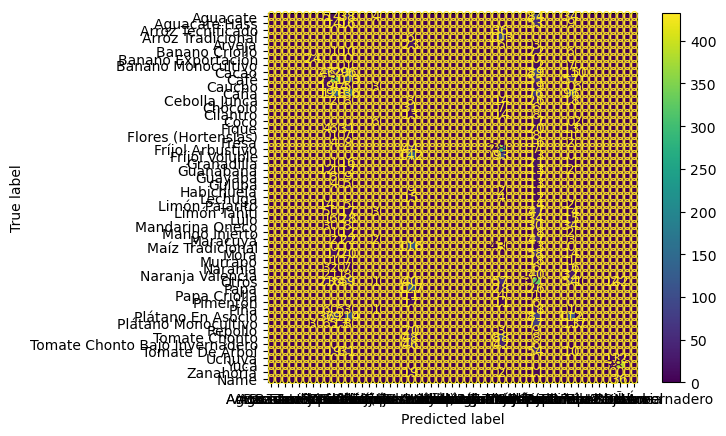



Modelo: KNeighborsClassifier(n_neighbors=3)


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El accuracy del modelo es: 0.29536768078275494
El recall del modelo es: 0.19517474813527871
La precision del modelo es: 0.2932608476119755
El f1 del modelo es: 0.1975393290459053


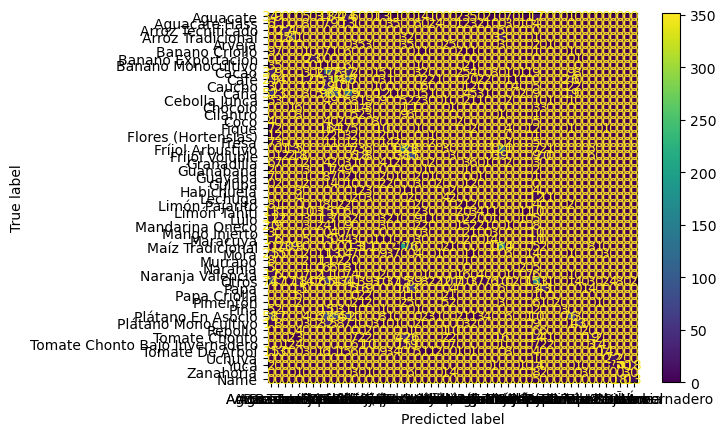



Modelo: LogisticRegression(C=1, max_iter=200, multi_class='ovr')
El accuracy del modelo es: 0.3114202721296438
El recall del modelo es: 0.131638496320328
La precision del modelo es: 0.1730240072193221
El f1 del modelo es: 0.12310526675458801


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


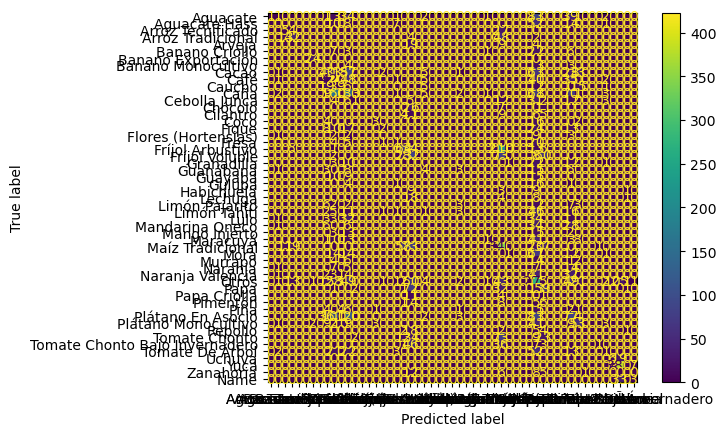



Modelo: DecisionTreeClassifier(max_depth=10, max_features='sqrt')
El accuracy del modelo es: 0.4195077205320287
El recall del modelo es: 0.22261693987416833
La precision del modelo es: 0.289432737487113
El f1 del modelo es: 0.2244285014589908


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


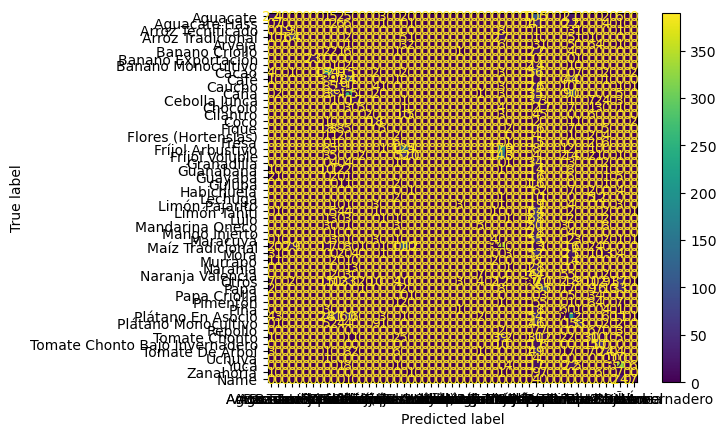



Modelo: RandomForestClassifier(max_depth=10)
El accuracy del modelo es: 0.5986852163277786


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El recall del modelo es: 0.32722549186400307
La precision del modelo es: 0.6027293175011523
El f1 del modelo es: 0.3585362956660581


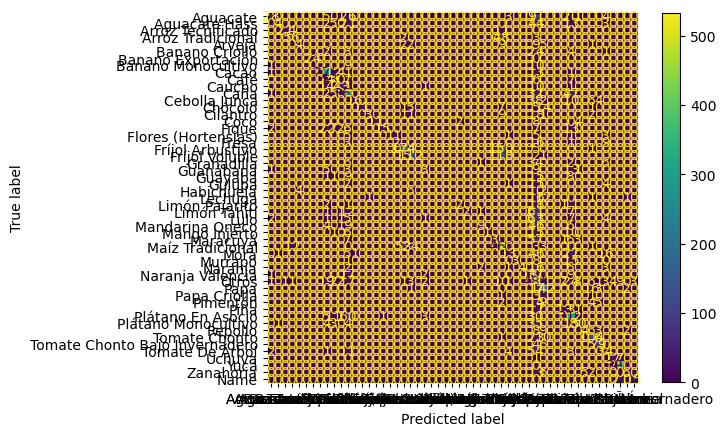



Modelo: GaussianNB(var_smoothing=1e-08)
El accuracy del modelo es: 0.09448096621311726
El recall del modelo es: 0.19023827544235658
La precision del modelo es: 0.13896578477260693
El f1 del modelo es: 0.06667592736081353


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


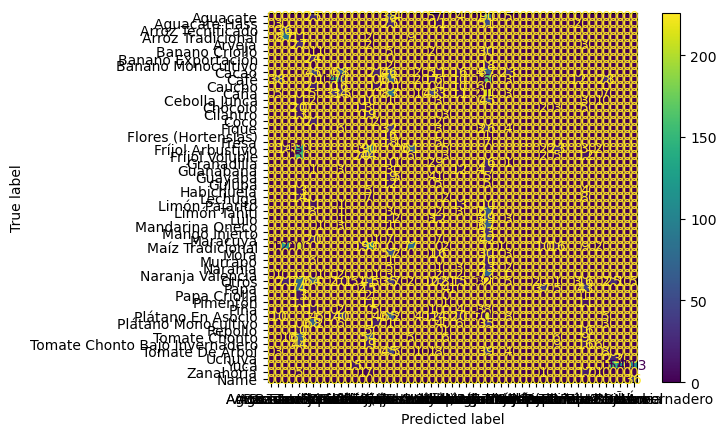

In [55]:
for i in lista_pipelines:
    print(f'Modelo: {i[-1]}')
    y_pred = i.predict(X_test)
    print(f'El accuracy del modelo es: {accuracy_score(y_test, y_pred)}')
    print(f'El recall del modelo es: {recall_score(y_test, y_pred, average="macro", zero_division=0)}')
    print(f'La precision del modelo es: {precision_score(y_test, y_pred, average="macro", zero_division=0)}')
    print(f'El f1 del modelo es: {f1_score(y_test, y_pred, average="macro", zero_division=0)}')

    mc = confusion_matrix(y_test, y_pred)
    image_matriz = ConfusionMatrixDisplay(confusion_matrix = mc, display_labels=le.classes_)
    image_matriz.plot()
    plt.show()
    
    print('\n')

In [ ]:
#para hacer FunctionTransformer nos basamos en
#https://www.youtube.com/watch?v=xIqX1dqcNbY

#para hacer ColumnTransformer nos basamos en
#https://www.youtube.com/watch?v=irHhDMbw3xo

#para hacer binary encoder nos basamos en
#https://www.youtube.com/watch?v=NuZuJL6TqI0

In [ ]:
#Conclusiones

ocurre porque estás usando funciones como recall_score, f1_score, y precision_score con el parámetro por defecto average='binary', que solo sirve para clasificación binaria (dos clases, como 0 y 1).

Pero tu problema es de clasificación multiclase, así que debes especificar un average apropiado.